# Chapter 5 Companion Notebook: Valuation and Asset Pricing

This notebook reproduces every worked numerical example from Chapter 5 of *AI in Finance* (`chapter5.tex`), including bond pricing, default-risk pricing, duration/convexity, portfolio duration, forward rates from the spot curve, WACC, the dividend discount model (Gordon and two-stage), preferred stock, relative valuation multiples, the one- and two-step binomial option model, American early exercise, Black-Scholes, the Greeks, delta hedging and its limits, implied volatility, the real-options option-to-wait example, and the closing Meridian DCF-versus-multiples valuation.

---

**© 2026 Wulin Suo. All rights reserved.** This notebook is a companion to the draft manuscript *AI in Finance* and is provided for personal, educational use. No part of this notebook may be reproduced, distributed, or transmitted in any form or by any means without the prior written permission of the author, except for brief quotations in a review. Contact: Wulin.Suo@Queensu.ca

## 1. Bond pricing and yield to maturity

A 3-year bond, face value \$1,000, 5% annual coupon, priced at a 7% market yield (Table~5.1 in the chapter).

In [1]:
import numpy as np
import pandas as pd

face = 1000.0
coupon_rate = 0.05
coupon = face * coupon_rate
y = 0.07
n = 3

cash_flows = [coupon] * (n - 1) + [coupon + face]
years = np.arange(1, n + 1)
discount_factors = 1 / (1 + y) ** years
present_values = cash_flows * discount_factors

bond_table = pd.DataFrame({
    'Year': years,
    'Cash flow': cash_flows,
    'Discount factor': discount_factors.round(4),
    'Present value': present_values.round(2),
})
price = present_values.sum()
print(bond_table.to_string(index=False))
print(f"\nBond price: ${price:,.2f}")

 Year  Cash flow  Discount factor  Present value
    1       50.0           0.9346          46.73
    2       50.0           0.8734          43.67
    3     1050.0           0.8163         857.11

Bond price: $947.51


In [2]:
# Macaulay duration: PV-weighted average time to receive cash flows
duration = np.sum(years * present_values) / price
print(f"Macaulay duration: {duration:.2f} years")

Macaulay duration: 2.86 years


### Yield to maturity by root-finding

Given an observed market price, YTM is the discount rate that reproduces it. For $n>1$ this has no closed form, so we solve it numerically, confirming it recovers the 7% used above.

In [3]:
from scipy.optimize import brentq

def bond_price(yld, cash_flows=cash_flows, years=years):
    return np.sum(np.array(cash_flows) / (1 + yld) ** years)

observed_price = 947.51
ytm = brentq(lambda yld: bond_price(yld) - observed_price, 0.0001, 1.0)
print(f"Implied yield to maturity: {ytm:.4%}")

Implied yield to maturity: 7.0001%


## 2. Pricing default risk

A one-year, zero-coupon corporate bond, face value \$1,000, risk-free rate 4%, default probability 3%, recovery rate 40% of face value.

In [4]:
rf = 0.04
p_default = 0.03
recovery = 0.40
face_corp = 1000.0

expected_payoff = (1 - p_default) * face_corp + p_default * recovery * face_corp
price_expected = expected_payoff / (1 + rf)
print(f"Expected payoff: ${expected_payoff:,.2f}")
print(f"Price (expected-cash-flow approach): ${price_expected:,.2f}")

# Credit-spread shortcut
credit_spread = p_default * (1 - recovery)
corp_yield = rf + credit_spread
price_spread = face_corp / (1 + corp_yield)
print(f"Credit spread: {credit_spread:.2%}, corporate yield: {corp_yield:.2%}")
print(f"Price (credit-spread approach): ${price_spread:,.2f}")

Expected payoff: $982.00
Price (expected-cash-flow approach): $944.23
Credit spread: 1.80%, corporate yield: 5.80%
Price (credit-spread approach): $945.18


## 3. Duration and the price-yield approximation

Modified duration gives a first-order approximation of how price responds to a yield change. We check the approximation against an exact repricing for both a yield increase and a yield decrease.

In [5]:
mod_duration = duration / (1 + y)
print(f"Modified duration: {mod_duration:.2f}")

def reprice(new_y, cash_flows=cash_flows, years=years):
    return np.sum(np.array(cash_flows) / (1 + new_y) ** years)

for dy in [0.01, -0.02]:
    approx_price = price * (1 - mod_duration * dy)
    exact_price = reprice(y + dy)
    print(f"dy={dy:+.2%} -> approx=${approx_price:,.2f}, "
          f"exact=${exact_price:,.2f}, error=${approx_price - exact_price:,.2f}")

Modified duration: 2.67
dy=+1.00% -> approx=$922.23, exact=$922.69, error=$-0.46
dy=-2.00% -> approx=$998.08, exact=$1,000.00, error=$-1.92


The approximation understates the true price in both directions, the signature of convexity: the price-yield curve is convex, so a straight-line (duration-only) approximation always lies below the true curve.

### Convexity: a second-order correction

Estimate convexity from three prices (at $y$, $y+1\%$, $y-1\%$) and add the second-order term to the duration approximation for the yield increase to 8%.

In [6]:
P0_conv = price
P_plus = reprice(y + 0.01)
P_minus = reprice(y - 0.01)
convexity = (P_plus + P_minus - 2 * P0_conv) / (P0_conv * 0.01 ** 2)
print(f"P0=${P0_conv:.2f}, P+=${P_plus:.2f}, P-=${P_minus:.2f}")
print(f"Convexity: {convexity:.2f}")

dy = 0.01
price_change_pct = -mod_duration * dy + 0.5 * convexity * dy**2
P_new_convexity = P0_conv * (1 + price_change_pct)
print(f"Duration+convexity price at y=8%: ${P_new_convexity:.2f}")
print(f"Exact repriced value:            ${reprice(y + dy):.2f}")

P0=$947.51, P+=$922.69, P-=$973.27
Convexity: 9.81
Duration+convexity price at y=8%: $922.69
Exact repriced value:            $922.69


## 4. Portfolio duration

60% of market value in the 3-year bond (duration 2.86 years), 40% in a 5-year zero-coupon bond (duration = maturity = 5 years).

In [7]:
weights_bonds = [0.6, 0.4]
durations_bonds = [duration, 5.0]
portfolio_duration = sum(w * d for w, d in zip(weights_bonds, durations_bonds))
print(f"Portfolio duration: {portfolio_duration:.2f} years")

Portfolio duration: 3.71 years


### 4b. Forward rates from the spot curve (Section 5.4)

Extract the implied 1-year forward rate (years 1-2) and 3-year forward rate (years 2-5) from the yield curve.

In [8]:
y1_curve, y2_curve, y5_curve = 0.042, 0.044, 0.048

f_12 = (1 + y2_curve) ** 2 / (1 + y1_curve) - 1
f_25 = ((1 + y5_curve) ** 5 / (1 + y2_curve) ** 2) ** (1 / 3) - 1
print(f"Forward rate f(1,2): {f_12:.4%}")
print(f"Forward rate f(2,5): {f_25:.4%}")

# Exercise: f(4,5) using 4-year (4.7%) and 5-year (4.8%) spot rates
y4_ex = 0.047
f_45_ex = (1 + y5_curve) ** 5 / (1 + y4_ex) ** 4 - 1
print(f"\nExercise -- Forward rate f(4,5): {f_45_ex:.4%}")

Forward rate f(1,2): 4.6004%
Forward rate f(2,5): 5.0675%

Exercise -- Forward rate f(4,5): 5.2010%


## 5. The cost of capital: CAPM and WACC

Meridian Fabrication's Year 2 figures (Chapter 4): equity $E=\$54.0$m, total debt $D=\$58.0$m. Risk-free rate 4%, market risk premium 6%, equity beta 1.2, pretax cost of debt 5%, tax rate 25%.

In [9]:
E, D_debt = 54.0, 58.0
rf_wacc, mrp, beta = 0.04, 0.06, 1.2
rd_pretax, tax_rate = 0.05, 0.25

re = rf_wacc + beta * mrp
rd_after_tax = rd_pretax * (1 - tax_rate)
wacc = (E / (E + D_debt)) * re + (D_debt / (E + D_debt)) * rd_after_tax

print(f"Cost of equity (CAPM): {re:.2%}")
print(f"After-tax cost of debt: {rd_after_tax:.2%}")
print(f"WACC: {wacc:.2%}")

# Sensitivity: beta of 1.5 instead of 1.2
beta_alt = 1.5
re_alt = rf_wacc + beta_alt * mrp
wacc_alt = (E / (E + D_debt)) * re_alt + (D_debt / (E + D_debt)) * rd_after_tax
print(f"With beta=1.5: cost of equity={re_alt:.2%}, WACC={wacc_alt:.2%}")

Cost of equity (CAPM): 11.20%
After-tax cost of debt: 3.75%
WACC: 7.34%
With beta=1.5: cost of equity=13.00%, WACC=8.21%


## 6. Dividend discount model (Gordon growth)

$D_1 = \$3.00$, required return $r = 9\%$, growth $g = 4\%$.

In [10]:
D1 = 3.00
r = 0.09
g = 0.04
P0 = D1 / (r - g)
print(f"Fair value P0: ${P0:,.2f}")

# Sensitivity: how much does P0 change if g rises by 1 percentage point?
for g_alt in [0.03, 0.04, 0.05, 0.06]:
    print(f"  g={g_alt:.0%} -> P0=${D1/(r-g_alt):,.2f}")

Fair value P0: $60.00
  g=3% -> P0=$50.00
  g=4% -> P0=$60.00
  g=5% -> P0=$75.00
  g=6% -> P0=$100.00


Notice how sharply the fair value rises as $g$ approaches $r$: this is the sensitivity warning from the chapter text made concrete.

### Two-stage dividend discount model

$D_0=\$3.00$, high growth $g_1=12\%$ for 3 years, then stable growth $g_2=4\%$ forever, required return $r=9\%$.

In [11]:
D0, g1, g2, r, n_high = 3.00, 0.12, 0.04, 0.09, 3

high_growth_divs = [D0 * (1 + g1) ** t for t in range(1, n_high + 1)]
pv_high_growth = sum(d / (1 + r) ** t for t, d in enumerate(high_growth_divs, start=1))

terminal_dividend = high_growth_divs[-1] * (1 + g2)
terminal_value = terminal_dividend / (r - g2)
pv_terminal = terminal_value / (1 + r) ** n_high

P0_two_stage = pv_high_growth + pv_terminal

print(f"High-growth dividends: {[round(d, 2) for d in high_growth_divs]}")
print(f"PV of high-growth dividends: ${pv_high_growth:.2f}")
print(f"Terminal value at year {n_high}: ${terminal_value:.2f}")
print(f"PV of terminal value: ${pv_terminal:.2f}")
print(f"Total price: ${P0_two_stage:.2f}")
print(f"Share of price from terminal value: {pv_terminal / P0_two_stage:.1%}")

High-growth dividends: [3.36, 3.76, 4.21]
PV of high-growth dividends: $9.50
Terminal value at year 3: $87.67
PV of terminal value: $67.70
Total price: $77.20
Share of price from terminal value: 87.7%


## 7. Preferred stock: a perpetuity special case

Preferred dividend $D=\$4.50$, required return $r=7.5\%$: the Gordon model with $g=0$.

In [12]:
D_pref = 4.50
r_pref = 0.075
P0_pref = D_pref / r_pref
print(f"Preferred stock value: ${P0_pref:,.2f}")

Preferred stock value: $60.00


## 8. Relative valuation: EV/EBITDA multiples

Meridian's EBIT (\$16.0m) + D&A (\$8.0m) = EBITDA of \$24.0m. Comparable firms trade at 6.5x EV/EBITDA.

In [13]:
ebit_meridian = 16.0
da_meridian = 8.0
ebitda_meridian = ebit_meridian + da_meridian
multiple = 6.5

ev_meridian = ebitda_meridian * multiple
total_debt_meridian = 58.0
cash_meridian = 9.0
net_debt_meridian = total_debt_meridian - cash_meridian
equity_value_multiples = ev_meridian - net_debt_meridian

print(f"EBITDA: ${ebitda_meridian:.1f}m")
print(f"Enterprise value: ${ev_meridian:.1f}m")
print(f"Net debt: ${net_debt_meridian:.1f}m")
print(f"Implied equity value: ${equity_value_multiples:.1f}m")

EBITDA: $24.0m
Enterprise value: $156.0m
Net debt: $49.0m
Implied equity value: $107.0m


## 9. One-step binomial option pricing

$S_0=\$50$, $u=1.2$, $d=0.9$, $R=1.04$, strike $K=\$50$.

In [14]:
S0, u, d, R, K = 50.0, 1.2, 0.9, 1.04, 50.0

Su, Sd = S0 * u, S0 * d
Cu, Cd = max(Su - K, 0), max(Sd - K, 0)
q = (R - d) / (u - d)
C0 = (q * Cu + (1 - q) * Cd) / R

print(f"Su=${Su:.2f}, Sd=${Sd:.2f}")
print(f"Cu=${Cu:.2f}, Cd=${Cd:.2f}")
print(f"Risk-neutral probability q: {q:.4f}")
print(f"Call price today: ${C0:.2f}")

Su=$60.00, Sd=$45.00
Cu=$10.00, Cd=$0.00
Risk-neutral probability q: 0.4667
Call price today: $4.49


## 10. Extending to two steps

Same stock and option over two periods, each still with $u=1.2$, $d=0.9$, $R=1.04$.

In [15]:
Suu, Sud, Sdd = S0 * u**2, S0 * u * d, S0 * d**2
Cuu, Cud, Cdd = max(Suu - K, 0), max(Sud - K, 0), max(Sdd - K, 0)
print(f"Suu=${Suu:.2f}, Sud=${Sud:.2f}, Sdd=${Sdd:.2f}")
print(f"Cuu=${Cuu:.2f}, Cud=${Cud:.2f}, Cdd=${Cdd:.2f}")

Cu_2step = (q * Cuu + (1 - q) * Cud) / R
Cd_2step = (q * Cud + (1 - q) * Cdd) / R
C0_2step = (q * Cu_2step + (1 - q) * Cd_2step) / R

print(f"Cu=${Cu_2step:.2f}, Cd=${Cd_2step:.2f}")
print(f"Two-step call price: ${C0_2step:.2f}")

Suu=$72.00, Sud=$54.00, Sdd=$40.50
Cuu=$22.00, Cud=$4.00, Cdd=$0.00
Cu=$11.92, Cd=$1.79
Two-step call price: $6.27


## 11. American options and early exercise

Same two-period tree, but an American put with strike $K=\$50$: compare immediate exercise to continuation value at every node.

In [16]:
Puu, Pud, Pdd = max(K - Suu, 0), max(K - Sud, 0), max(K - Sdd, 0)

# Down node: compare continuation value to immediate exercise
Pd_cont = (q * Pud + (1 - q) * Pdd) / R
Pd_exercise = max(K - (S0 * d), 0)
Pd_american = max(Pd_cont, Pd_exercise)
print(f"Down node: continuation=${Pd_cont:.2f}, exercise=${Pd_exercise:.2f}, American value=${Pd_american:.2f}")

# Up node
Pu_cont = (q * Puu + (1 - q) * Pud) / R
Pu_exercise = max(K - (S0 * u), 0)
Pu_american = max(Pu_cont, Pu_exercise)
print(f"Up node: continuation=${Pu_cont:.2f}, exercise=${Pu_exercise:.2f}, American value=${Pu_american:.2f}")

# Today
P0_cont = (q * Pu_american + (1 - q) * Pd_american) / R
P0_exercise = max(K - S0, 0)
P0_american = max(P0_cont, P0_exercise)
print(f"Today: continuation=${P0_cont:.2f}, exercise=${P0_exercise:.2f}, American put value=${P0_american:.2f}")

# European put for comparison: no early-exercise check, just discount terminal payoffs
Pd_european = (q * Pud + (1 - q) * Pdd) / R
Pu_european = (q * Puu + (1 - q) * Pud) / R
P0_european = (q * Pu_european + (1 - q) * Pd_european) / R
print(f"European put value: ${P0_european:.2f}")
print(f"Early-exercise premium: ${P0_american - P0_european:.2f}")

Down node: continuation=$4.87, exercise=$5.00, American value=$5.00
Up node: continuation=$0.00, exercise=$0.00, American value=$0.00
Today: continuation=$2.56, exercise=$0.00, American put value=$2.56
European put value: $2.50
Early-exercise premium: $0.07


## 12. Black-Scholes model and put-call parity

Same $S_0=K=\$50$, with $r=4\%$, $\sigma=30\%$, $T=1$ year.

In [17]:
from scipy.stats import norm
import math

S0, K, r, sigma, T = 50.0, 50.0, 0.04, 0.30, 1.0

d1 = (math.log(S0 / K) + (r + sigma**2 / 2) * T) / (sigma * math.sqrt(T))
d2 = d1 - sigma * math.sqrt(T)

call = S0 * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)
put = K * math.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

print(f"d1={d1:.4f}, d2={d2:.4f}")
print(f"N(d1)={norm.cdf(d1):.4f}, N(d2)={norm.cdf(d2):.4f}")
print(f"Call price: ${call:.2f}")
print(f"Put price: ${put:.2f}")
print(f"Call delta (N(d1)): {norm.cdf(d1):.4f}")

d1=0.2833, d2=-0.0167
N(d1)=0.6115, N(d2)=0.4934
Call price: $6.88
Put price: $4.92
Call delta (N(d1)): 0.6115


In [18]:
# Put-call parity check: C + K*e^{-rT} should equal P + S0
lhs = call + K * math.exp(-r * T)
rhs = put + S0
print(f"C + K*e^(-rT) = ${lhs:.2f}")
print(f"P + S0        = ${rhs:.2f}")
assert abs(lhs - rhs) < 1e-8, "Put-call parity violated -- check inputs!"
print("Put-call parity holds.")

C + K*e^(-rT) = $54.92
P + S0        = $54.92
Put-call parity holds.


## 13. The Greeks: measuring an option's risk exposures

Evaluated at the same inputs as the Black-Scholes example above.

In [19]:
delta = norm.cdf(d1)
gamma = norm.pdf(d1) / (S0 * sigma * math.sqrt(T))
vega = S0 * norm.pdf(d1) * math.sqrt(T)
theta = -(S0 * norm.pdf(d1) * sigma) / (2 * math.sqrt(T)) - r * K * math.exp(-r * T) * norm.cdf(d2)
rho = K * T * math.exp(-r * T) * norm.cdf(d2)

print(f"Delta: {delta:.4f}")
print(f"Gamma: {gamma:.4f}")
print(f"Vega:  {vega:.2f} (per unit vol, i.e. per 100 vol points)")
print(f"Theta: {theta:.2f} per year (~${theta/365:.4f} per calendar day)")
print(f"Rho:   {rho:.2f}")

Delta: 0.6115
Gamma: 0.0255
Vega:  19.16 (per unit vol, i.e. per 100 vol points)
Theta: -3.82 per year (~$-0.0105 per calendar day)
Rho:   23.70


### 13b. Delta hedging and its limits (Section 5.11)

A market maker short 1,000 calls delta-hedges with 611.5 shares. Recompute the exact new option price after a $1 move and compare to the delta and delta-gamma approximations.

In [20]:
def bs_call(S, K=K, r=r, sigma=sigma, T=T):
    d1_ = (math.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * math.sqrt(T))
    d2_ = d1_ - sigma * math.sqrt(T)
    return S * norm.cdf(d1_) - K * math.exp(-r * T) * norm.cdf(d2_)

n_contracts = 1000
shares_held = n_contracts * delta

S_up = 51.0
C_up = bs_call(S_up)
stock_pnl = shares_held * (S_up - S0)
option_pnl = -n_contracts * (C_up - call)
net_pnl = stock_pnl + option_pnl
print(f"C_new (S=51): ${C_up:.4f}")
print(f"Stock P&L: ${stock_pnl:.2f}, Option P&L: ${option_pnl:.2f}, Net P&L: ${net_pnl:.2f}")

C_approx_delta = call + delta * (S_up - S0)
C_approx_dg = call + delta * (S_up - S0) + 0.5 * gamma * (S_up - S0) ** 2
print(f"Delta-only approx: ${C_approx_delta:.4f}, Delta-gamma approx: ${C_approx_dg:.4f}, Actual: ${C_up:.4f}")

# Exercise: stock falls to $49 instead of rising to $51
S_down = 49.0
C_down = bs_call(S_down)
stock_pnl_down = shares_held * (S_down - S0)
option_pnl_down = -n_contracts * (C_down - call)
net_pnl_down = stock_pnl_down + option_pnl_down
print(f"\nExercise (S=49) -- C_new: ${C_down:.4f}, Stock P&L: ${stock_pnl_down:.2f}, "
      f"Option P&L: ${option_pnl_down:.2f}, Net P&L: ${net_pnl_down:.2f}")

C_new (S=51): $7.5008
Stock P&L: $611.54, Option P&L: $-624.15, Net P&L: $-12.61
Delta-only approx: $7.4882, Delta-gamma approx: $7.5009, Actual: $7.5008

Exercise (S=49) -- C_new: $6.2780, Stock P&L: $-611.54, Option P&L: $598.60, Net P&L: $-12.94


## 14. Implied volatility

The same call is observed trading in the market at \$7.50 instead of the \$6.88 model price. Solve for the volatility that reproduces the market price.

In [21]:
def bs_call_price(sigma_input, S0=S0, K=K, r=r, T=T):
    d1_ = (math.log(S0 / K) + (r + sigma_input**2 / 2) * T) / (sigma_input * math.sqrt(T))
    d2_ = d1_ - sigma_input * math.sqrt(T)
    return S0 * norm.cdf(d1_) - K * math.exp(-r * T) * norm.cdf(d2_)

market_price = 7.50
implied_vol = brentq(lambda s: bs_call_price(s) - market_price, 0.001, 3.0)
print(f"Implied volatility: {implied_vol:.4%}")
print(f"Check -- BS price at implied vol: ${bs_call_price(implied_vol):.2f}")

Implied volatility: 33.2544%
Check -- BS price at implied vol: $7.50


### 14b. The VIX: a market-wide implied volatility index (Section 5.12)

Download the actual daily history of the CBOE Volatility Index (VIX) from Yahoo Finance and plot it, marking several of its largest historical spikes.

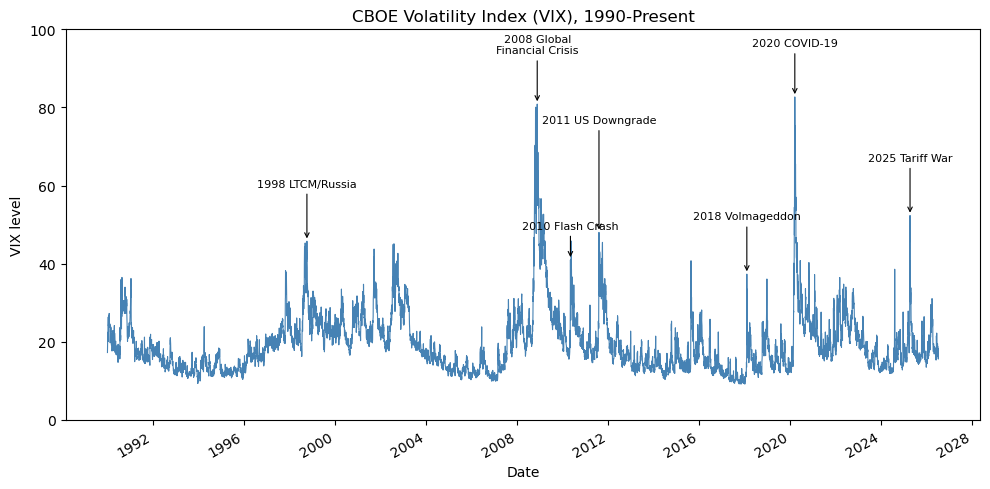

Data range: 1990-01-02 to 2026-07-08, 9196 observations
All-time max: 82.69 on 2020-03-16
All-time min: 9.14 on 2017-11-03
1998 LTCM/Russia: 45.74
2008 Global Financial Crisis: 80.86
2010 Flash Crash: 40.95
2011 US Downgrade: 48.00
2018 Volmageddon: 37.32
2020 COVID-19: 82.69
2025 Tariff War: 52.33


In [22]:
import yfinance as yf
import matplotlib.pyplot as plt

vix = yf.download("^VIX", start="1990-01-01", progress=False, auto_adjust=False)["Close"]
if isinstance(vix, pd.DataFrame):
    vix = vix.iloc[:, 0]
vix = vix.dropna()

# (label, event date, vertical label offset in VIX points)
events = {
    "1998 LTCM/Russia": ("1998-10-08", 14),
    "2008 Global\nFinancial Crisis": ("2008-11-20", 13),
    "2010 Flash Crash": ("2010-05-07", 8),
    "2011 US Downgrade": ("2011-08-08", 28),
    "2018 Volmageddon": ("2018-02-05", 14),
    "2020 COVID-19": ("2020-03-16", 13),
    "2025 Tariff War": ("2025-04-08", 14),
}

fig, ax = plt.subplots(figsize=(10, 5))
vix.plot(ax=ax, color="steelblue", linewidth=0.8)
for label, (date_str, offset) in events.items():
    event_date = pd.Timestamp(date_str)
    event_val = float(vix.loc[event_date])
    ax.annotate(label, xy=(event_date, event_val), xytext=(event_date, event_val + offset),
                arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
                fontsize=8, ha="center")
ax.set_title("CBOE Volatility Index (VIX), 1990-Present")
ax.set_ylabel("VIX level")
ax.set_xlabel("Date")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("../ch5_fig_vix.png", dpi=150)
plt.show()

print(f"Data range: {vix.index[0].date()} to {vix.index[-1].date()}, {len(vix)} observations")
print(f"All-time max: {vix.max():.2f} on {vix.idxmax().date()}")
print(f"All-time min: {vix.min():.2f} on {vix.idxmin().date()}")
for label, (date_str, offset) in events.items():
    print(f"{label.replace(chr(10), ' ')}: {float(vix.loc[pd.Timestamp(date_str)]):.2f}")

## 15. Convergence of the binomial model to Black-Scholes

The chapter's hand-computed one- and two-step trees use fixed $u=1.2$, $d=0.9$, chosen for hand-computability rather than to represent a specific step size. A tree built for an arbitrary number of steps instead derives $u$ and $d$ from the annualized volatility using the Cox-Ross-Rubinstein (CRR) parametrization $u=e^{\sigma\sqrt{\Delta t}}$, $d=1/u$, so that the tree's step-level variance always matches the same $\sigma=30\%$ used in the Black-Scholes example, however many steps it has. We verify convergence by pricing the same at-the-money call ($S_0=K=\$50$, $r=4\%$, $\sigma=30\%$, $T=1$ year) with an increasing number of CRR binomial steps, up to 5,000.

In [23]:
from scipy.stats import binom

def binomial_call(S0, K, r, sigma, T, n_steps):
    dt = T / n_steps
    u = math.exp(sigma * math.sqrt(dt))
    d = 1 / u
    R = math.exp(r * dt)
    q = (R - d) / (u - d)

    # terminal stock prices and payoffs; j = number of down-moves
    j = np.arange(n_steps + 1)
    ST = S0 * u**(n_steps - j) * d**j
    payoffs = np.maximum(ST - K, 0)

    # P(j down-moves) = C(n_steps,j) q^(n_steps-j) (1-q)^j
    #                  = P(n_steps-j up-moves) = binom.pmf(n_steps-j, n_steps, q)
    # binom.pmf avoids the overflow that comb(n_steps, j) * q**... suffers
    # for large n_steps, since comb(5000, 2500) alone exceeds float64 range.
    probs = binom.pmf(n_steps - j, n_steps, q)
    price = np.exp(-r * T) * np.sum(probs * payoffs)
    return price

print(f"Black-Scholes price: ${call:.4f}\n")
for steps in [1, 2, 5, 20, 100, 500, 1000, 5000]:
    price = binomial_call(S0, K, r, sigma, T, steps)
    error = price - call
    print(f"{steps:>5} steps -> call price ${price:.4f}  (error ${error:+.4f})")

Black-Scholes price: $6.8766

    1 steps -> call price $8.2786  (error $+1.4019)
    2 steps -> call price $6.2060  (error $-0.6706)
    5 steps -> call price $7.1616  (error $+0.2849)
   20 steps -> call price $6.8034  (error $-0.0732)
  100 steps -> call price $6.8619  (error $-0.0147)
  500 steps -> call price $6.8737  (error $-0.0029)
 1000 steps -> call price $6.8752  (error $-0.0015)
 5000 steps -> call price $6.8763  (error $-0.0003)


## 16. Putting it together: valuing Meridian Fabrication

DCF: FCF of -\$2.0m, \$3.0m, \$6.0m in Years 3-5, then growing at $g=3\%$ forever, discounted at the WACC computed above. Compare to the multiples-based equity value from Section 8.

In [24]:
fcf_years_3_5 = [-2.0, 3.0, 6.0]
g_terminal = 0.03
discount_rate = wacc

pv_fcf = sum(cf / (1 + discount_rate) ** (t + 1) for t, cf in enumerate(fcf_years_3_5))
print(f"PV of Years 3-5 FCF: ${pv_fcf:.2f}m")

fcf_year6 = fcf_years_3_5[-1] * (1 + g_terminal)
terminal_value_5 = fcf_year6 / (discount_rate - g_terminal)
pv_terminal_5 = terminal_value_5 / (1 + discount_rate) ** 5
print(f"Terminal value at Year 5: ${terminal_value_5:.2f}m")
print(f"PV of terminal value: ${pv_terminal_5:.2f}m")

ev_dcf = pv_fcf + pv_terminal_5
equity_value_dcf = ev_dcf - net_debt_meridian
print(f"DCF enterprise value: ${ev_dcf:.2f}m")
print(f"DCF implied equity value: ${equity_value_dcf:.2f}m")

print(f"\nMultiples-based equity value: ${equity_value_multiples:.1f}m")
print(f"DCF equity value:             ${equity_value_dcf:.2f}m")
print(f"Meridian's book value of equity: $54.0m")

PV of Years 3-5 FCF: $5.59m
Terminal value at Year 5: $142.33m
PV of terminal value: $99.87m
DCF enterprise value: $105.47m
DCF implied equity value: $56.47m

Multiples-based equity value: $107.0m
DCF equity value:             $56.47m
Meridian's book value of equity: $54.0m


## 17. Real options: the option to wait (Section 5.13)

A mining deposit costs $K=\$50$m to develop and is worth exactly \$50m if developed today (NPV = 0). Waiting one year, its value moves to \$70m or \$35m with equal probability; the firm only develops if still profitable at that point.

In [25]:
K_real = 50.0
V_up, V_down = 70.0, 35.0
p_real = 0.5
r_real = 0.05

npv_today = 50.0 - K_real
payoff_up = max(V_up - K_real, 0)
payoff_down = max(V_down - K_real, 0)
expected_payoff = p_real * payoff_up + (1 - p_real) * payoff_down
pv_wait = expected_payoff / (1 + r_real)

print(f"NPV if developed today: ${npv_today:.2f}m")
print(f"Payoff up: ${payoff_up:.2f}m, payoff down: ${payoff_down:.2f}m")
print(f"Expected payoff from waiting: ${expected_payoff:.2f}m")
print(f"PV of waiting one year: ${pv_wait:.2f}m")
print(f"Value of the option to wait: ${pv_wait - npv_today:.2f}m")

NPV if developed today: $0.00m
Payoff up: $20.00m, payoff down: $0.00m
Expected payoff from waiting: $10.00m
PV of waiting one year: $9.52m
Value of the option to wait: $9.52m


## Exercises (match Chapter 5, Suggested Exercises)

Use the code cells above as templates to solve:

1. Price a 2-year, 6%-coupon, \$1,000 face-value bond at an 8% yield.
2. Value a stock with $D_1=\$2.50$, $r=10\%$, under both $g=6\%$ and $g=8\%$.
3. Price a call with the one-step binomial model using $S_0=\$40$, $u=1.25$, $d=0.8$, $R=1.05$, $K=\$40$.

In [26]:
# Exercise 1: bond pricing
face, coupon_rate, y, n = 1000.0, 0.06, 0.08, 2
cash_flows_ex = [face * coupon_rate] * (n - 1) + [face * coupon_rate + face]
years_ex = np.arange(1, n + 1)
price_ex = np.sum(np.array(cash_flows_ex) / (1 + y) ** years_ex)
print(f"Exercise 1 -- bond price: ${price_ex:,.2f}")

# Exercise 2: dividend discount model
for g_ex in [0.06, 0.08]:
    print(f"Exercise 2 -- g={g_ex:.0%} -> P0=${2.50/(0.10-g_ex):,.2f}")

# Exercise 3: binomial call
S0_ex, u_ex, d_ex, R_ex, K_ex = 40.0, 1.25, 0.8, 1.05, 40.0
Su_ex, Sd_ex = S0_ex*u_ex, S0_ex*d_ex
Cu_ex, Cd_ex = max(Su_ex-K_ex,0), max(Sd_ex-K_ex,0)
q_ex = (R_ex - d_ex) / (u_ex - d_ex)
C0_ex = (q_ex*Cu_ex + (1-q_ex)*Cd_ex) / R_ex
print(f"Exercise 3 -- q={q_ex:.4f}, call price=${C0_ex:.2f}")

Exercise 1 -- bond price: $964.33
Exercise 2 -- g=6% -> P0=$62.50
Exercise 2 -- g=8% -> P0=$125.00
Exercise 3 -- q=0.5556, call price=$5.29


4. Compute the modified-duration price approximation for a bond with Macaulay duration 2.86 years, priced at \$947.51 at $y=7\%$, if the yield falls to 6\%. Compare it to an exact repricing.
5. Value a stock with $D_0=\$2.00$, high growth $g_1=15\%$ for 4 years, terminal growth $g_2=5\%$, and $r=11\%$ using the two-stage model.

In [27]:
# Exercise 4: duration approximation for a yield decrease to 6%
dy_ex = -0.01
approx_ex4 = 947.51 * (1 - mod_duration * dy_ex)
exact_ex4 = reprice(0.07 + dy_ex)
print(f"Exercise 4 -- approx=${approx_ex4:,.2f}, exact=${exact_ex4:,.2f}")

# Exercise 5: two-stage DDM
D0_ex, g1_ex, g2_ex, r_ex, n_ex = 2.00, 0.15, 0.05, 0.11, 4
divs_ex = [D0_ex * (1 + g1_ex) ** t for t in range(1, n_ex + 1)]
pv_high_ex = sum(d / (1 + r_ex) ** t for t, d in enumerate(divs_ex, start=1))
term_val_ex = divs_ex[-1] * (1 + g2_ex) / (r_ex - g2_ex)
pv_term_ex = term_val_ex / (1 + r_ex) ** n_ex
P0_ex = pv_high_ex + pv_term_ex
print(f"Exercise 5 -- price=${P0_ex:.2f}, "
      f"terminal share={pv_term_ex/P0_ex:.1%}")

Exercise 4 -- approx=$972.79, exact=$973.27
Exercise 5 -- price=$49.07, terminal share=82.2%
